<a href="https://colab.research.google.com/github/juliagermanosilva-pixel/Desafio_ETL-/blob/main/Desafio_ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df_hotel = pd.read_csv('/content/hotel_dataset_messy.csv')
display(df_hotel.head(3))

,Guest_Name,Age,Room_Type,CheckIn_Date,CheckOut_Date,Booking_Channel,Total_Charges,Satisfaction_Score
0,pAulo chiavini,69,Standard,2025-08-21,2025-08-23,Site Oficial,296.967888,1.0
1,aNa pereira,32,Standard,2025-08-28,2025-09-10,Booking.com,2235.383385,5.0
2,luYz silva,78,Standard,2025-01-04,2025-01-18,Site Oficial,1907.702878,4.0


/tmp/ipykernel_3096/883038463.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Noites', data=df_hotel, palette='viridis')


Text(0, 0.5, 'Contagem')

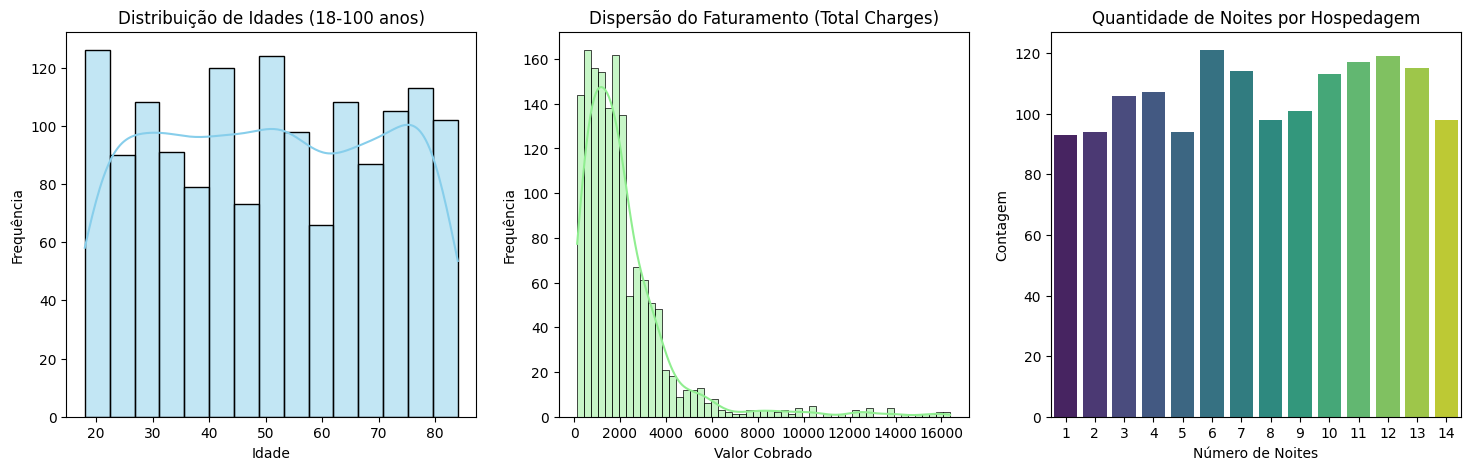

In [9]:
# 1 - limpar dados e filtrar - idades entre 18 e 100
df_hotel = df_hotel[(df_hotel['Age'] >= 18) & (df_hotel['Age'] <= 100)]
# 2 - Corrigir faturamento - negativos deixar positivo
df_hotel['Total_Charges'] = df_hotel['Total_Charges'].abs()
# 3 - Criar uma Nova Métrica: O sistema não diz quantas noites a pessoa ficou. Você precisa calcular isso subtraindo o Check-in do Check-out.
df_hotel['CheckIn_Date'] = pd.to_datetime(df_hotel['CheckIn_Date'])
df_hotel['CheckOut_Date'] = pd.to_datetime(df_hotel['CheckOut_Date'])
df_hotel['Noites'] = (df_hotel['CheckOut_Date'] - df_hotel['CheckIn_Date']).dt.days
# 4 - Visualização - criar 3 gráficos lado a lado
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(18, 5))
plt.subplot(1,3,1)
sns.histplot(df_hotel['Age'], bins=15, kde=True, color='skyblue')
plt.title('Distribuição de Idades (18-100 anos)')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.subplot(1,3,2)
sns.histplot(df_hotel['Total_Charges'], kde=True, color='lightgreen')
plt.title('Dispersão do Faturamento (Total Charges)')
plt.xlabel('Valor Cobrado')
plt.ylabel('Frequência')


plt.subplot(1,3,3)
sns.countplot(x='Noites', data=df_hotel, palette='viridis')
plt.title('Quantidade de Noites por Hospedagem')
plt.xlabel('Número de Noites')
plt.ylabel('Contagem')